## Graph features analysis

In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import networkx as nx
from networkx.algorithms import community

%matplotlib inline


In [2]:
RANDOM_STATE=90

In [3]:
np.random.seed(RANDOM_STATE)

## Load Data

In [4]:
datafolder = './data'
data = os.path.join(datafolder, "1", "elliptic_bitcoin_dataset","elliptic_txs_features.csv")

datafolder = os.path.join(datafolder, "1","elliptic_bitcoin_dataset")   


In [5]:
cols = ['txId','time_step']


local_cols = [f'lf_{i+1}' for i in range(93)]
agg_cols = [f'af_{i+1}' for i in range(72)]

cols += local_cols + agg_cols

In [6]:
feature_cols = local_cols + agg_cols

In [7]:
features = pd.read_csv(os.path.join(datafolder, "elliptic_txs_features.csv"),  index_col=False, names=cols,)
edges = pd.read_csv(os.path.join(datafolder, "elliptic_txs_edgelist.csv"))
classes = pd.read_csv(os.path.join(datafolder, "elliptic_txs_classes.csv"))


In [8]:
# map classes: licit - 0; illicit- 1;  unknown -2
class_mapping = {'2': 0, '1': 1, 'unknown': 2}
classes.replace({"class": class_mapping}, inplace=True).astype(int)
classes['class'].value_counts()

class
2    157205
0     42019
1      4545
Name: count, dtype: int64

In [9]:
df = pd.merge(features, classes, on='txId')

## Graph analysis

In [10]:
# create graph
graph = nx.Graph()

graph = nx.from_pandas_edgelist(edges, 'txId1', 'txId2')

In [27]:
# sample [for visualization] by class
classes_sampled = classes.groupby('class').sample(frac=0.2, random_state=RANDOM_STATE)
txIds_sampled = classes_sampled['txId']

# get samples edges: 
edges_sampled = edges[edges['txId1'].isin(txIds_sampled) | edges['txId2'].isin(txIds_sampled)]

# extract sample features:
features_sampled = features[features['txId'].isin(txIds_sampled)]

print(f"Sampled Classes:\n{classes_sampled['class'].value_counts()}\n")
print(f"Sampled Edgelist: {edges_sampled.shape[0]:,}")
print(f"Sampled Features: {features_sampled.shape[0]:,}")

Sampled Classes:
class
2    31441
0     8404
1      909
Name: count, dtype: int64

Sampled Edgelist: 85,161
Sampled Features: 40,754


## Graph Connectivity

In [12]:
num_nodes = features.shape[0]
num_edges = edges.shape[0]

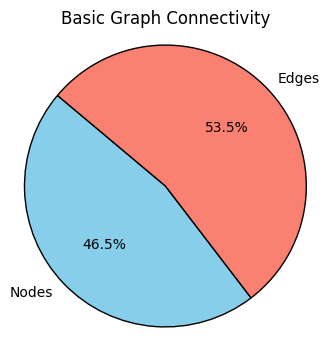

In [13]:
plt.figure(figsize=(4, 4))
sizes = [num_nodes, num_edges]
labels = ['Nodes', 'Edges']
colors = ['skyblue', 'salmon']
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, 
        wedgeprops = {'edgecolor' : 'black', 
                      'linewidth': 1, 
                      'antialiased': True})
plt.title('Basic Graph Connectivity')
plt.axis('equal')
plt.show()



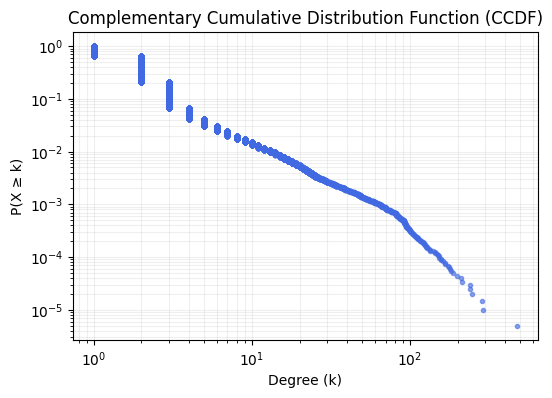

In [14]:
# degree distribution

degrees = sorted([d for n, d in graph.degree()], reverse=True)

# 2. Calculate the CCDF
# For each degree k, what fraction of nodes have degree >= k?
n = len(degrees)
y = np.arange(1, n + 1) / n
x = degrees

plt.figure(figsize=(6, 4))
plt.loglog(x, y, marker='.', linestyle='none', color='royalblue', alpha=0.6)

plt.title("Complementary Cumulative Distribution Function (CCDF)")
plt.xlabel("Degree (k)")
plt.ylabel("P(X ≥ k)")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()



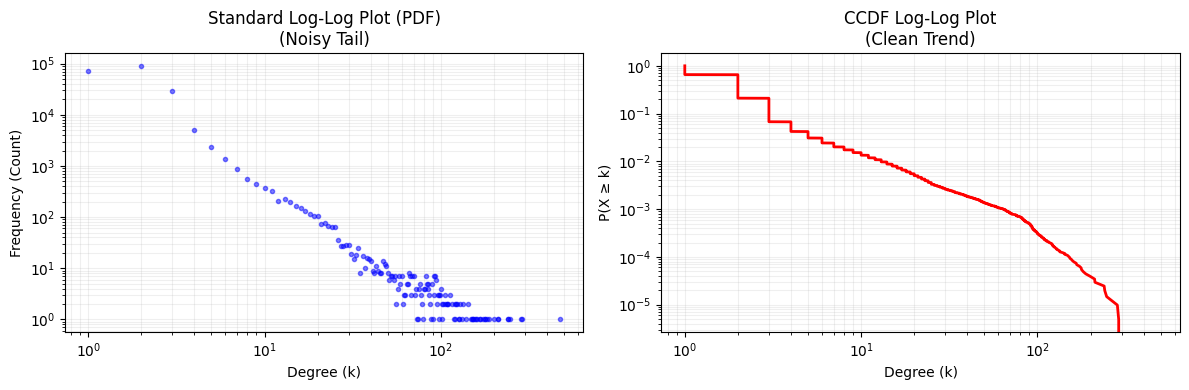

In [15]:
degree_counts = np.bincount(degrees)
k = np.nonzero(degree_counts)[0]
counts = degree_counts[k]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.loglog(k, counts, 'bo', markersize=3, alpha=0.5)
ax1.set_title("Standard Log-Log Plot (PDF)\n(Noisy Tail)")
ax1.set_xlabel("Degree (k)")
ax1.set_ylabel("Frequency (Count)")
ax1.grid(True, which="both", ls="-", alpha=0.2)

# --- 2. CCDF Plot ---
# This is the "Optimal" version
sorted_degrees = np.sort(degrees)
n = len(sorted_degrees)
# Probability P(X >= k)
y = 1.0 - np.arange(1, n + 1) / n

ax2.loglog(sorted_degrees, y, color='red', linewidth=2)
ax2.set_title("CCDF Log-Log Plot\n(Clean Trend)")
ax2.set_xlabel("Degree (k)")
ax2.set_ylabel("P(X ≥ k)")
ax2.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.savefig('comparison_plot.png')
plt.show()

> most of the nodes - $10^5$, are in the range of degree of 1-5. only a small amount have close to 100 connections.

- the time steps are unconnected graphs
- each time step graphs is composed of 1 subgraph - no unconnected nodes inside a timesteps. 

In [16]:
# number of subgraphs - one for each timestep. 

num_connected_components = nx.number_connected_components(graph)
print(f"Number of connected components: {num_connected_components}")


Number of connected components: 49


In [28]:
G = nx.from_pandas_edgelist(edges, 'txId1', 'txId2')
g_sampled = nx.from_pandas_edgelist(edges_sampled, 'txId1','txId2' )

In [29]:
# explore the largest graph
max_component = max(nx.connected_components(g_sampled), key=len)
G_max = g_sampled.subgraph(max_component)

print(f"Number of nodes: {G_max.number_of_nodes():,}")
print(f"Number of edges: {G_max.number_of_edges():,}")

Number of nodes: 1,991
Number of edges: 2,247


In [30]:
# create a directed version of the largest subgraph in the sample (for EDA)

G_d = nx.from_pandas_edgelist(
      edges_sampled,          
      source='txId1',
      target='txId2',
      create_using=nx.DiGraph()
  )


# Get G-max directed: the largest subgraph in the sample: 

max_component = max(nx.weakly_connected_components(G_d), key=len)
G_max_directed = G_d.subgraph(max_component)

print(f"Number of nodes: {G_max_directed.number_of_nodes():,}")
print(f"Number of edges: {G_max_directed.number_of_edges():,}")

Number of nodes: 1,991
Number of edges: 2,247


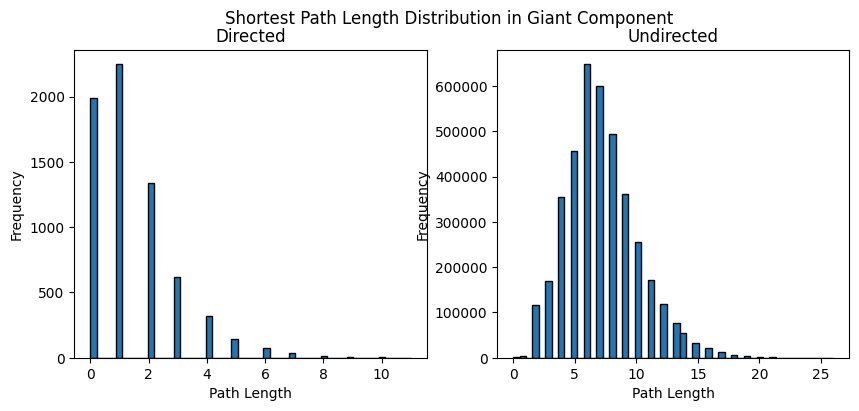

In [31]:
# Shortest paths length distribution in G max
path_lengths_d = dict(nx.shortest_path_length(G_max_directed))
path_lengths = dict(nx.shortest_path_length(G_max))
path_lengths_values = [length for target_lengths in path_lengths.values() for length in target_lengths.values()]
path_lengths_values_d = [length for target_lengths_d in path_lengths_d.values() for length in target_lengths_d.values()]

path_list = [path_lengths_values_d, path_lengths_values]

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10, 4))

for i, ax in enumerate([ax1,ax2]):
    ax.hist(path_list[i], bins=50, edgecolor='black')
    ax.set_xlabel('Path Length')
    ax.set_ylabel('Frequency')
ax1.set_title('Directed')
ax2.set_title('Undirected')
plt.suptitle('Shortest Path Length Distribution in Giant Component')
plt.show()

this corresponds to the low degree for most nodes - most of the nodes have multiple steps between them, going through several hubs. Deepest walk is 12.

## Node Centrality

### Degree centrality: 

number of direct connections a node has in a network $$C_D(v)=\frac{deg(v)}{N−1}$$

where N-1 is the number of possible edges. 

In [32]:
degree_centrality = nx.degree_centrality(G_max)
top_degree_centrality = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:15]
df_top_degree_centrality = pd.DataFrame(top_degree_centrality, columns=['Node', 'Degree Centrality'])

print("Top 10 nodes by degree centrality:")
print("==================================")
print(df_top_degree_centrality.head(10))



Top 10 nodes by degree centrality:
       Node  Degree Centrality
0  68705820           0.124121
1  43397277           0.091457
2  43479990           0.036181
3  43388675           0.031658
4  43387917           0.024121
5  68706499           0.019598
6  43451301           0.014070
7    565334           0.012563
8  42667105           0.011558
9  43331434           0.011558


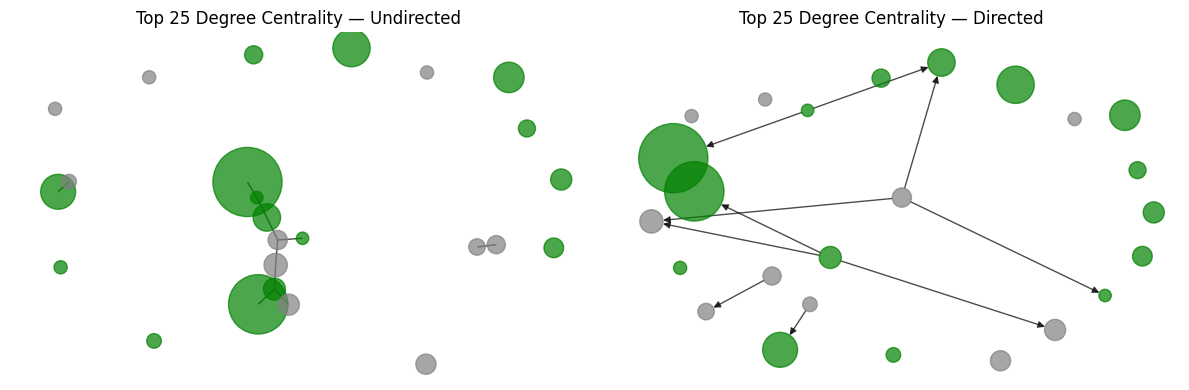

In [ ]:
def plot_centrality_measure(graph, centrality_scores, metric_name, ax, n_top=25, size_coeff = 20000):                                                                                                      
    top_nodes = sorted(centrality_scores, key=centrality_scores.get, reverse=True)[:n_top]                                                                                             
    subgraph  = graph.subgraph(top_nodes)                                                                                                                                              
                                                                                                                                                                                        
    node_colors = [centrality_scores[node] for node in subgraph.nodes()]                                                                                                               
    norm = mpl.colors.Normalize(vmin=min(node_colors), vmax=max(node_colors))                                                                                                          
    cmap = plt.cm.cool                                                                                                                                                                 
                                                                                                                                                                                        
    # map colors by label
    label_map = dict(zip(classes['txId'], classes['class']))
    color_dict = {0: 'green', 1: 'red', 2: 'grey'}
    inner_nodes = list(subgraph.nodes())

    node_colors = [color_dict[label_map.get(node)] for node in inner_nodes]

    # dynamic size based on rank
    node_sizes = [centrality_scores[node] * size_coeff for node in inner_nodes]

    pos = nx.spring_layout(subgraph, seed=RANDOM_STATE)                                                                                                                                          
    nx.draw(subgraph, pos, ax=ax, with_labels=False,                                                                                                                    
            alpha=0.7, node_color=node_colors, node_size= node_sizes, cmap=cmap)                                                                                                                              

    graph_type = 'Directed' if isinstance(graph, nx.DiGraph) else 'Undirected'                                                                                                         
    ax.set_title(f'Top {n_top} {metric_name} — {graph_type}') 


    # sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)                                                                                                                                   
    # sm.set_array([])                                                                                                                                                                   
    # plt.colorbar(sm, ax=ax, label=metric_name)                                                                                                                                         
                                                                                                                                                                                        


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))                                                                                                                                  
for ax, graph in zip([ax1, ax2], [G_max, G_max_directed]):                                                                                                                             
    scores = nx.degree_centrality(graph)
    plot_centrality_measure(graph, scores, 'Degree Centrality', ax)                                                                                                                    
plt.tight_layout()
plt.show()  


### Betweenness Centrality

In [45]:
# betweenness centrality: in how many shortest paths does the node stand - is it a 'must' stop in the way? 
betweenness_centrality = nx.betweenness_centrality(G_max)
top_betweenness_centrality = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:15]
df_top_betweenness_centrality = pd.DataFrame(top_betweenness_centrality, columns=['Node', 'Betweenness Centrality'])

print("Top 10 nodes by betweenness centrality:")
print("=======================================")
print(df_top_betweenness_centrality.head(10))

Top 10 nodes by betweenness centrality:
       Node  Betweenness Centrality
0  68705820                0.494600
1  43397277                0.363169
2  43479990                0.250167
3  43388675                0.194350
4  43451301                0.178469
5  68706499                0.153732
6    565334                0.110932
7  43387917                0.100181
8  43388016                0.059790
9  42649854                0.053352


/home/tiggi/Documents/IU_projects/bitcoin_rec/cc_fraud_NMF/.venv/lib/python3.12/site-packages/networkx/drawing/nx_pylab.py:1497: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


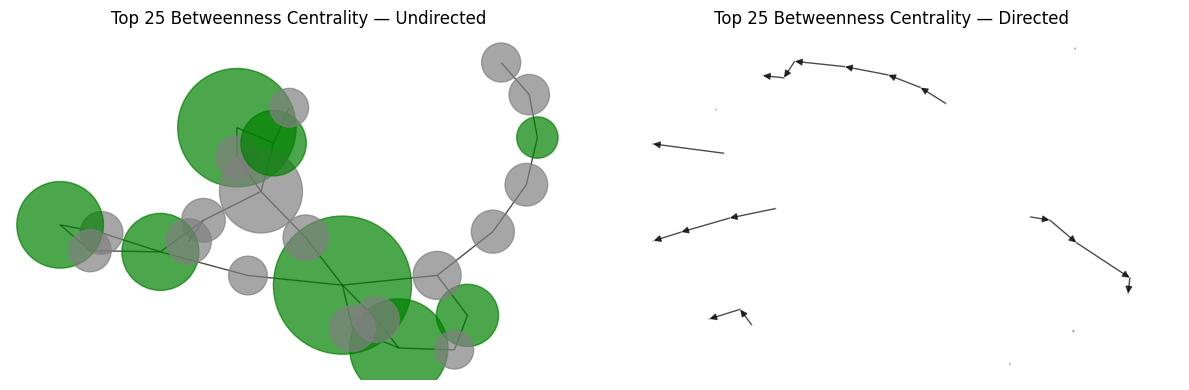

In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for ax, graph in zip([ax1, ax2], [G_max, G_max_directed]):                                                                                                                             
    scores = nx.betweenness_centrality(graph)
    plot_centrality_measure(graph, scores, 'Betweenness Centrality', ax)                                                                                                               
plt.tight_layout()
plt.show() 

### Closeness centrality   

In [47]:
# closeness centrality -  how close a node is to the center of the network
closeness_centrality = nx.closeness_centrality(G_max)
top_closeness_centrality = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:15]
df_top_closeness_centrality = pd.DataFrame(top_closeness_centrality, columns=['Node', 'Closeness Centrality'])

print("Top 10 nodes by closeness centrality:")
print("=====================================")
print(df_top_closeness_centrality.head(10))

Top 10 nodes by closeness centrality:
       Node  Closeness Centrality
0  68705820              0.220157
1  43479990              0.211860
2  43451301              0.206968
3  19062329              0.205218
4  42649854              0.205028
5  36664822              0.205028
6  43397277              0.204249
7  37730682              0.203622
8  34557715              0.203581
9  22171617              0.203581


/home/tiggi/Documents/IU_projects/bitcoin_rec/cc_fraud_NMF/.venv/lib/python3.12/site-packages/networkx/drawing/nx_pylab.py:1497: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


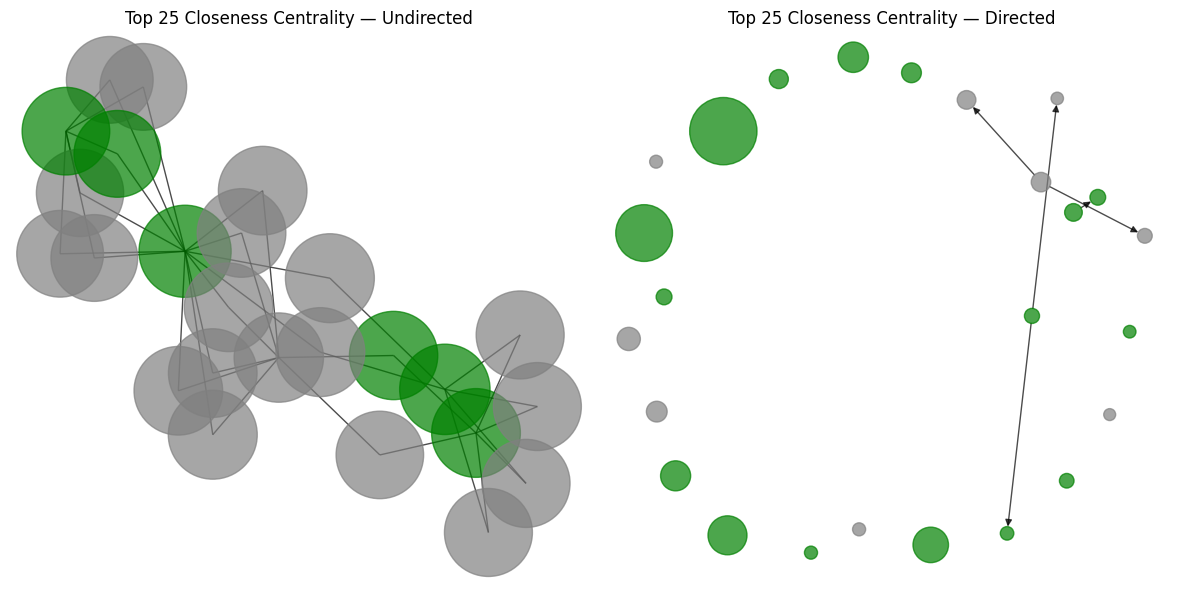

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
for ax, graph in zip([ax1, ax2], [G_max, G_max_directed]):                                                                                                                             
    scores = nx.closeness_centrality(graph)
    plot_centrality_measure(graph, scores, 'Closeness Centrality', ax)                                                                                                               
plt.tight_layout()
plt.show() 

### Eigenvector Centrality

eigenvector centrality measures a node's influence based on how many influential nodes it is connected to.

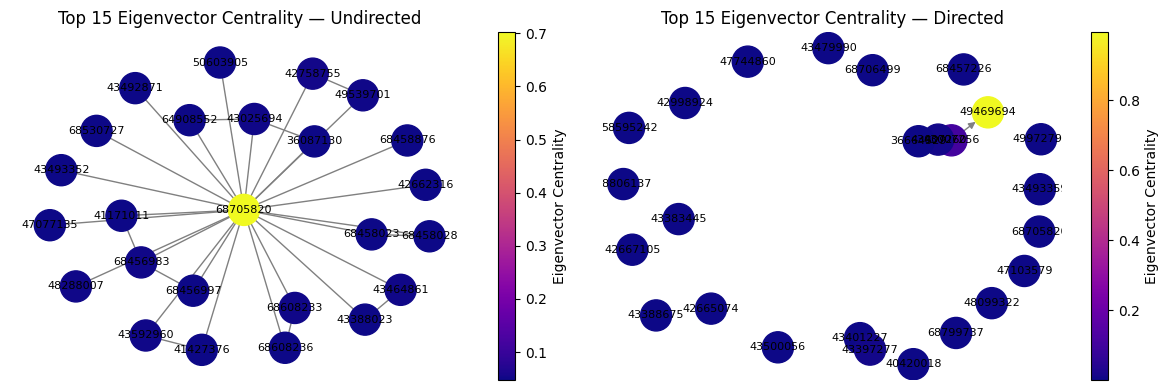

In [51]:
# eigenvector centrality: a node is important if it has important nodes in its neighborhood

def calc_eigen_centrality(graph, ax):
      eigen_centrality = nx.eigenvector_centrality(graph, max_iter=1000)

      top_nodes_eigen = sorted(eigen_centrality, key=eigen_centrality.get, reverse=True)[:25]
      subgraph_eigen  = graph.subgraph(top_nodes_eigen)

      node_colors = [eigen_centrality[node] for node in subgraph_eigen.nodes()]
      norm = mpl.colors.Normalize(vmin=min(node_colors), vmax=max(node_colors))
      cmap = plt.cm.plasma

      pos = nx.spring_layout(subgraph_eigen, seed=RANDOM_STATE)
      nx.draw(subgraph_eigen, pos, ax=ax, with_labels=True, node_size=500,
              edge_color='gray', font_size=8, node_color=node_colors,
              cmap=cmap, arrowsize=10)

      return norm, cmap


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for ax, graph, title in zip([ax1, ax2],
                               [G_max, G_max_directed],
                               ['Undirected', 'Directed']):
      norm, cmap = calc_eigen_centrality(graph, ax)
      sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
      sm.set_array([])
      plt.colorbar(sm, ax=ax, label='Eigenvector Centrality')
      ax.set_title(f'Top 15 Eigenvector Centrality — {title}')

plt.tight_layout()
plt.show()


we can see that there is one node in this subset of the subgraph, that has high centrality measures for all metrics. 

### Page Rank

Ranks the nodes by how many nodes point to them. 
each pointing node sends a 'score' of its own rank, averaged by how many outlinks it has. the inlinks are the sum of incoming pointing.

In [52]:
pagerank_scores = nx.pagerank(G_max_directed, alpha=0.85)
top_nodes = sorted(pagerank_scores, key=pagerank_scores.get, reverse=True)[:50]
subgraph_pr = G_max_directed.subgraph(top_nodes)

/home/tiggi/Documents/IU_projects/bitcoin_rec/cc_fraud_NMF/.venv/lib/python3.12/site-packages/networkx/drawing/nx_pylab.py:1497: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


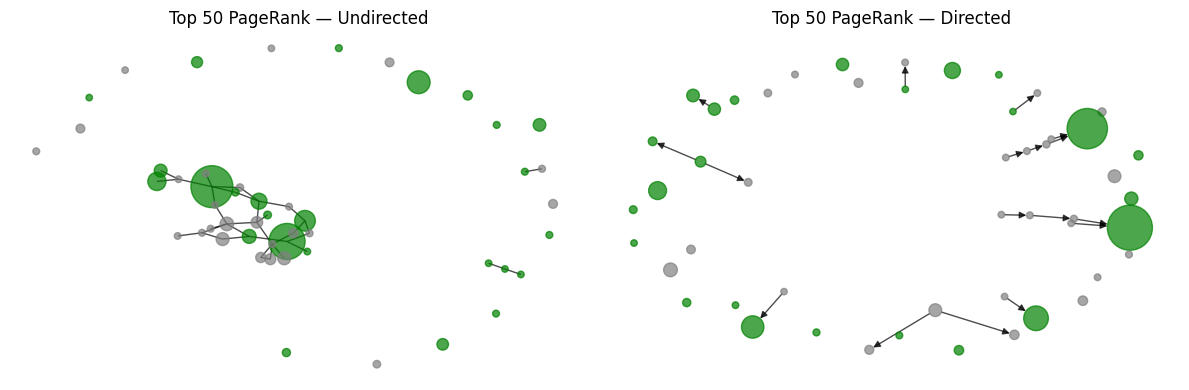

In [53]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))                                                                                                                                  
for ax, graph in zip([ax1, ax2], [G_max, G_max_directed]):
    scores = nx.pagerank(graph, alpha=0.85)                                                                                                                                            
    plot_centrality_measure(graph, scores, 'PageRank', ax, n_top=50)
plt.tight_layout()
plt.show()


measures the proximity to the center of the graph

In [41]:
# map colors by label
label_map = dict(zip(classes['txId'], classes['class']))
color_dict = {0: 'green', 1: 'red', 2: 'grey'}

inner_nodes = list(subgraph_pr.nodes())
node_colors = [color_dict[label_map.get(node)] for node in inner_nodes]

# dynamic size based on rank
node_sizes = [pagerank_scores[node] * 20000 for node in inner_nodes]

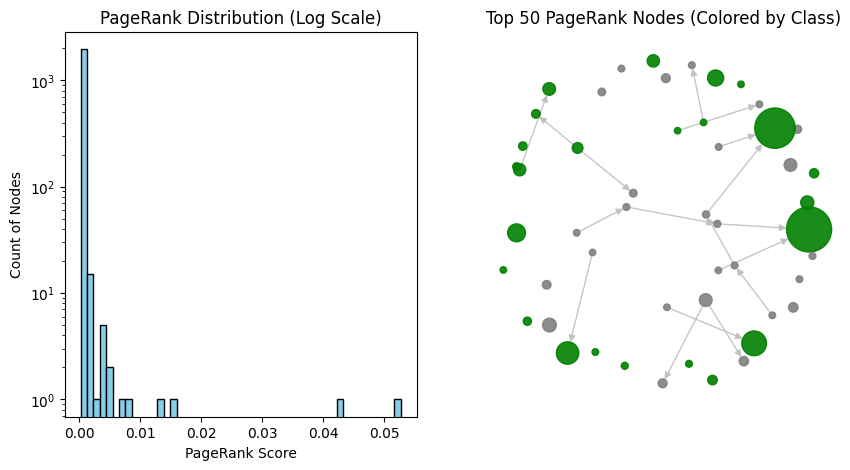

In [54]:
plt.figure(figsize=(10, 5))
# --- Plot A: Distribution (The 'Power Law' check) ---
plt.subplot(1, 2, 1)
plt.hist(list(pagerank_scores.values()), bins=50, log=True, color='skyblue', edgecolor='black')
plt.title("PageRank Distribution (Log Scale)")
plt.xlabel("PageRank Score")
plt.ylabel("Count of Nodes")

# --- Plot B: The Top 10 Subgraph ---
ax2 = plt.subplot(1, 2, 2)
pos = nx.spring_layout(subgraph_pr, k=0.5, seed=RANDOM_STATE) # k controls distance between nodes

nx.draw(subgraph_pr, pos, 
        ax=ax2,
        with_labels=False, 
        node_color=node_colors, 
        node_size=node_sizes, 
        edge_color='silver', 
        alpha=0.9, 
        font_size=9,
        font_weight='bold')

plt.title("Top 50 PageRank Nodes (Colored by Class)")
plt.axis('off')
plt.show()

### Bridging nodes (Burt's coefficient)

meaningful structural hole brokers are nodes that bridge dense subgraphs (communities) — they have diverse, non-redundant connections. Low Burt's constraint in a well-connected neighborhood = true broker. Low constraint because you only have 2 connections = probably just sparsity artifact.

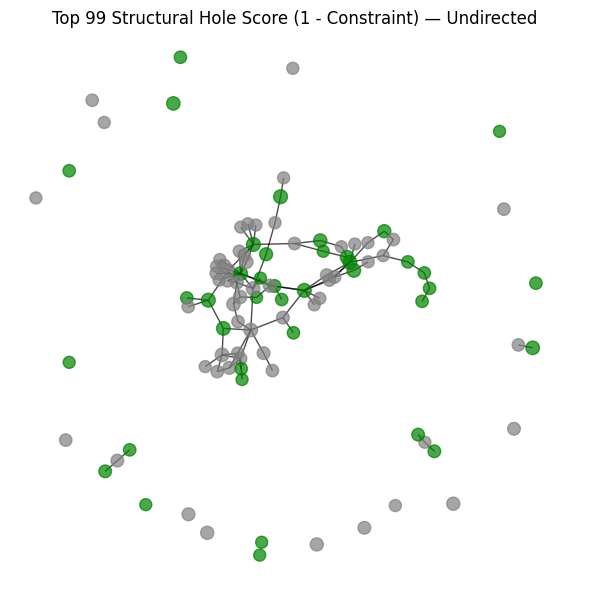

In [61]:
# Structural holes — Burt's constraint
# low constraint = structural hole broker, high = constrained (neighbors all know each other)                                                                                          
constraint = nx.constraint(G_max)                                                                                                                                                      
                                                                                                                                                                                        
# invert so high = more holes = more bridging (easier to interpret)                                                                                                                    
structural_hole_score = {node: 1 - c for node, c in constraint.items() if c is not None}
                                                                                                                                                                                        
top_holes = sorted(structural_hole_score, key=structural_hole_score.get, reverse=True)[:99]
subgraph_holes = G_max.subgraph(top_holes)                                                                                                                                             
                                                                                                                                                                                        
fig, ax = plt.subplots(figsize=(6, 6))                                                                                                                                                 
plot_centrality_measure(G_max, structural_hole_score, 'Structural Hole Score (1 - Constraint)', ax, size_coeff=100, n_top=99)                                                                                    
plt.tight_layout()                                                                                                                                                                     
plt.show()

Bridging nodes in a sparse graph are trickey. throughout the EDA we see that there are 'lines' in the graph, more than interconnected communities. here it is visible that many nodes are bridging nodes, alone from this structure. it is also visible that the size of the nodes doesnt change - the coefficient is similar to most of the top nodes. 

### HITS

Hubs/Authorities

hubs - send flows to many receiveres
Authorities - receive flows from 'important' hubs. 

the hubs might represent the mixing services. they allocate the flows differently to other transactions. 
authorities - can represent legit platforms. 

In [62]:
# for hits, only the directed graph is required


hubs, authorities = nx.hits(G_max_directed, max_iter=1000)

top_hubs = sorted(hubs, key=hubs.get, reverse=True)[:30]
top_auths = sorted(authorities, key=authorities.get, reverse=True)[:50]

# combine to 1 graph
hits_nodes = list(set(top_hubs) | set(top_auths))
subgraph_hits = G_max_directed.subgraph(hits_nodes)




/home/tiggi/Documents/IU_projects/bitcoin_rec/cc_fraud_NMF/.venv/lib/python3.12/site-packages/matplotlib/collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/home/tiggi/Documents/IU_projects/bitcoin_rec/cc_fraud_NMF/.venv/lib/python3.12/site-packages/networkx/drawing/nx_pylab.py:1747: RuntimeWarning: invalid value encountered in sqrt
  return self.np.sqrt(marker_size) / 2


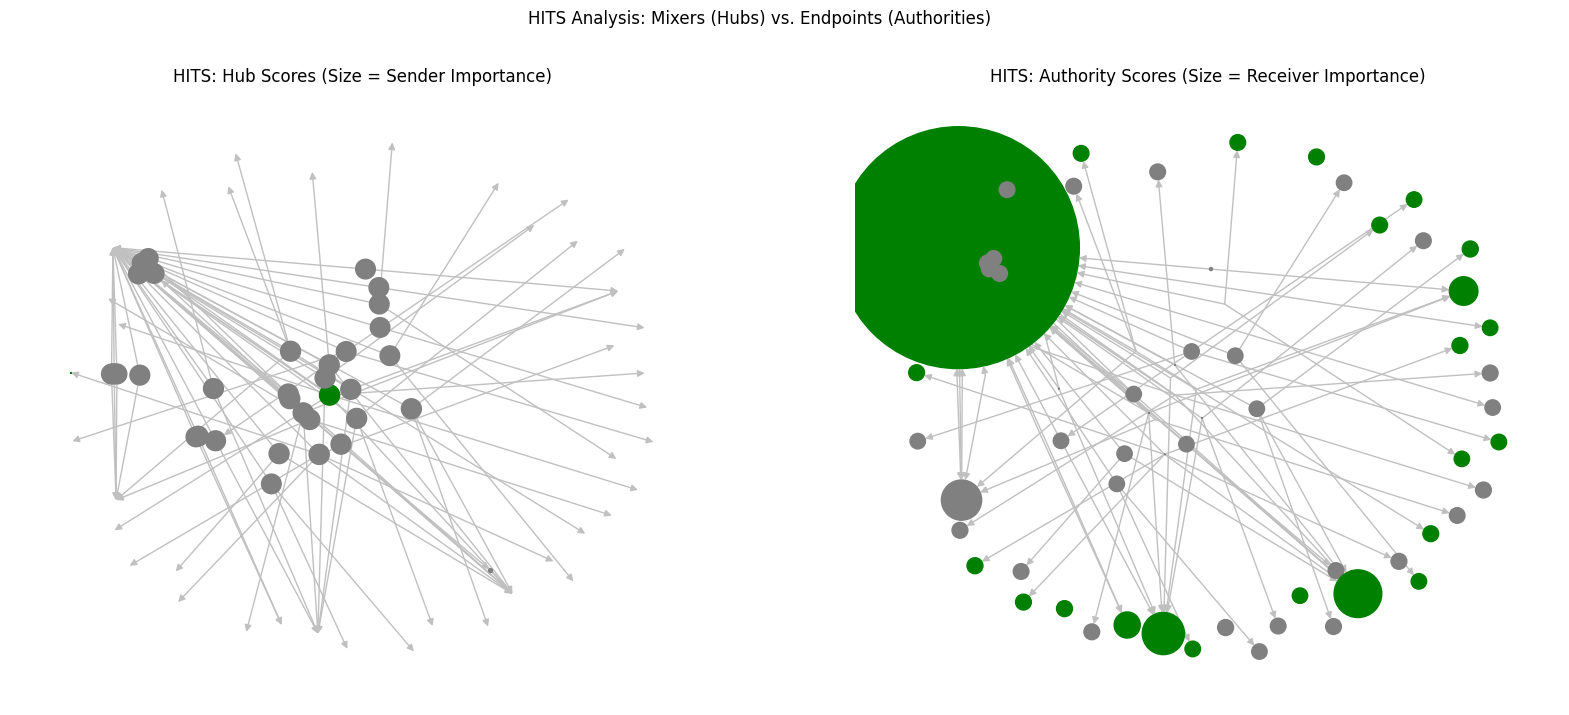

In [63]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
pos = nx.spring_layout(subgraph_hits, seed=RANDOM_STATE)
node_colors = [color_dict[label_map.get(n, 2)] for n in subgraph_hits.nodes()]

# --- AX1: Focus on HUB Scores ---
hub_sizes = [hubs[n] * 50000 for n in subgraph_hits.nodes()]
nx.draw(subgraph_hits, pos, ax=ax1, with_labels=False, 
        node_size=hub_sizes, node_color=node_colors, edge_color='silver')
ax1.set_title("HITS: Hub Scores (Size = Sender Importance)")

# --- AX2: Focus on AUTHORITY Scores ---
auth_sizes = [authorities[n] * 50000 for n in subgraph_hits.nodes()]
nx.draw(subgraph_hits, pos, ax=ax2, with_labels=False, 
        node_size=auth_sizes, node_color=node_colors, edge_color='silver')
ax2.set_title("HITS: Authority Scores (Size = Receiver Importance)")

plt.suptitle("HITS Analysis: Mixers (Hubs) vs. Endpoints (Authorities)")
plt.show()

### Reciprocity

Checks hwether transactions go both ways

Overall reciprocity: 0.0000
Fraction of nodes with zero reciprocity: 100.00%


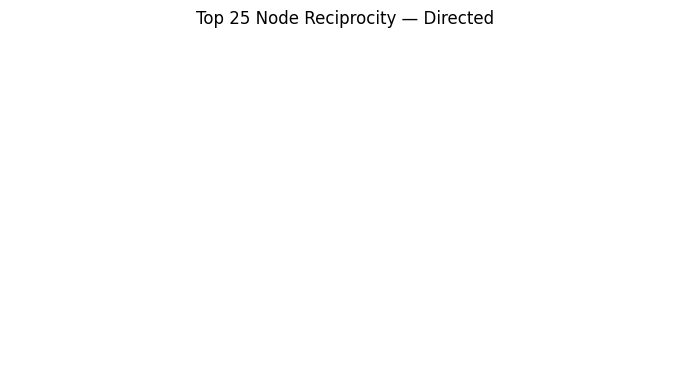

In [64]:
print(f"Overall reciprocity: {nx.overall_reciprocity(G_max_directed):.4f}")

# per-node: fraction of out-edges that have a matching in-edge
def node_reciprocity(G):
    rec = {}
    for node in G.nodes():
        out_nb = set(G.successors(node))
        in_nb  = set(G.predecessors(node))
        rec[node] = len(out_nb & in_nb) / len(out_nb) if out_nb else 0.0
    return rec

node_rec = node_reciprocity(G_max_directed)
print(f"Fraction of nodes with zero reciprocity: "
    f"{sum(1 for v in node_rec.values() if v == 0) / len(node_rec):.2%}")

fig, ax = plt.subplots(figsize=(7, 4))
plot_centrality_measure(G_max_directed, node_rec, 'Node Reciprocity', ax)
plt.tight_layout()
plt.show()

## Community detection

### Lovain

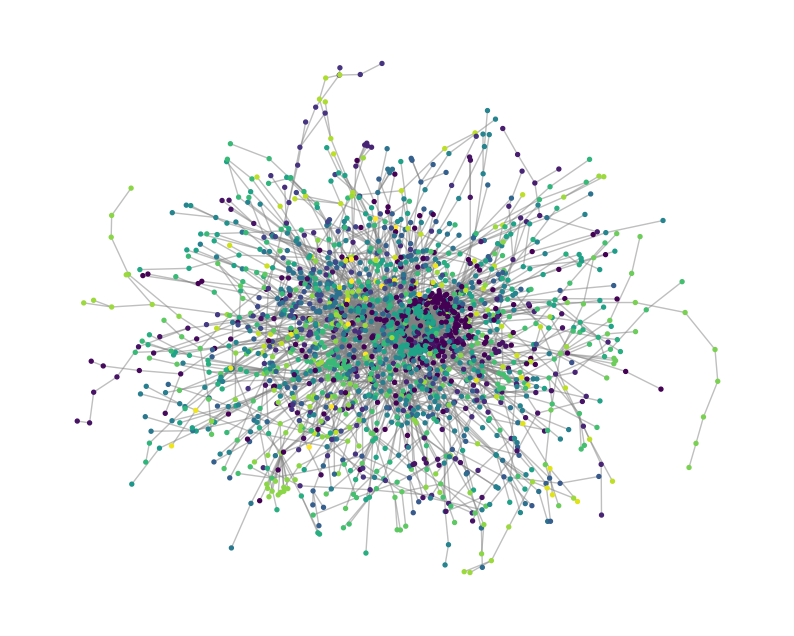

In [68]:

# Compute best partition.
comms = community.louvain_communities(G_max)
node_to_community = {}
for i, group in enumerate(comms):
    for node in group:
        node_to_community[node] = i


node_colors = [node_to_community[node] for node in G_max.nodes()]

# Draw graph.
plt.figure(figsize=(10, 8))

pos = nx.spring_layout(G_max)
cmap = plt.get_cmap('viridis')
nx.draw_networkx_nodes(G_max, pos, node_color=node_colors, node_size=8, cmap=cmap)
nx.draw_networkx_edges(G_max, pos, alpha=0.5, edge_color='grey')
plt.axis('off')

plt.show()



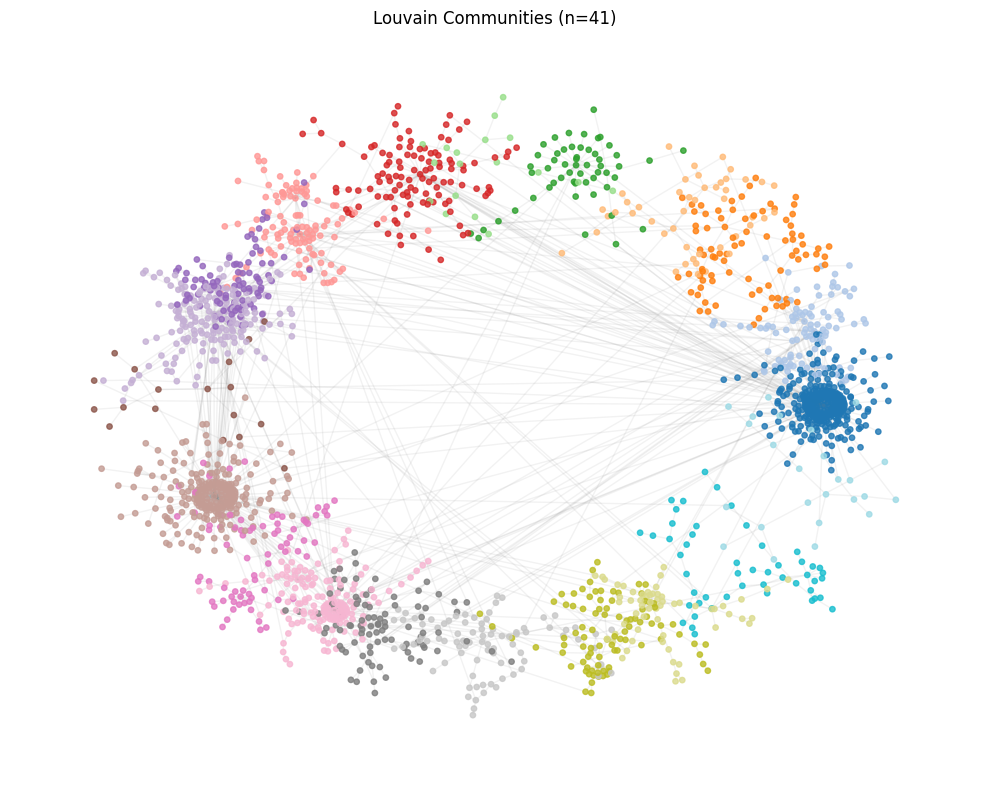

In [ ]:
def community_layout(G, communities, scale=0.3):
    n = len(communities)                                                                                                   
    pos = {}                                                                                                               
    for i, comm in enumerate(communities):
        # community centers arranged in a circle                                                                           
        angle  = 2 * np.pi * i / n              
        center = np.array([np.cos(angle), np.sin(angle)])                                                                  
        # nodes within community laid out locally around that center
        sub_pos = nx.spring_layout(G.subgraph(comm), seed=RANDOM_STATE, scale=scale)                                                 
        for node, p in sub_pos.items():                                                                                    
            pos[node] = center + p                                                                                         
    return pos                                                                                                             
                                                                                                                            
fig, ax = plt.subplots(figsize=(10, 8))
pos = community_layout(G_max, comms)                                                                                       
n_comms = len(comms)                
cmap = plt.get_cmap('tab20', n_comms)   # categorical, not sequential                                                      
node_colors = [node_to_community[n] for n in G_max.nodes()]          
                                                                                                                            
nx.draw_networkx_nodes(G_max, pos, node_color=node_colors, node_size=15,                                                   
                        cmap=cmap, alpha=0.8, ax=ax)                                                                        
nx.draw_networkx_edges(G_max, pos, alpha=0.1, edge_color='grey', ax=ax)                                                    
ax.set_title(f'Louvain Communities (n={n_comms})')                                                                         
ax.axis('off')                                                                                                             
plt.tight_layout()                                                                                                         
plt.show() 

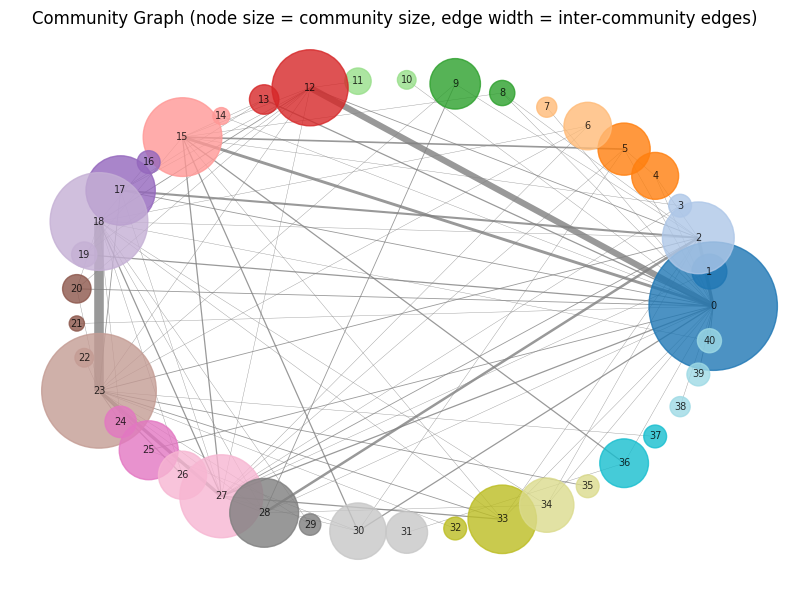

In [74]:
# community plots 

comm_graph = nx.Graph()                                                                                                    
for i, comm in enumerate(comms):
    comm_graph.add_node(i, size=len(comm))                                                                                 
                                                                                                                            
for u, v in G_max.edges():
    cu, cv = node_to_community[u], node_to_community[v]                                                                    
    if cu != cv:                                       
        if comm_graph.has_edge(cu, cv):
            comm_graph[cu][cv]['weight'] = comm_graph[cu][cv].get('weight', 1) + 1                                         
        else:                                                                     
            comm_graph.add_edge(cu, cv, weight=1)                                                                          
                                                                                                                            
sizes  = [comm_graph.nodes[i]['size'] * 30 for i in comm_graph.nodes()]
widths = [comm_graph[u][v]['weight'] * 0.3 for u, v in comm_graph.edges()]                                                 
                                                                        
fig, ax = plt.subplots(figsize=(8, 6))                                                                                     
pos = nx.circular_layout(comm_graph)
nx.draw(comm_graph, pos, ax=ax,                                                                                            
        node_size=sizes, width=widths,                                                                                     
        node_color=range(n_comms), cmap=plt.get_cmap('tab20', n_comms),
        edge_color='grey', alpha=0.8, with_labels=True, font_size=7)                                                       
ax.set_title('Community Graph (node size = community size, edge width = inter-community edges)')
plt.tight_layout()                                                                                                         
plt.show() 


Timestep 25: 2314 nodes, 2619 edges
Communities found: 43
Community sizes: [193, 187, 136, 133, 103, 95, 91, 77, 76, 75]


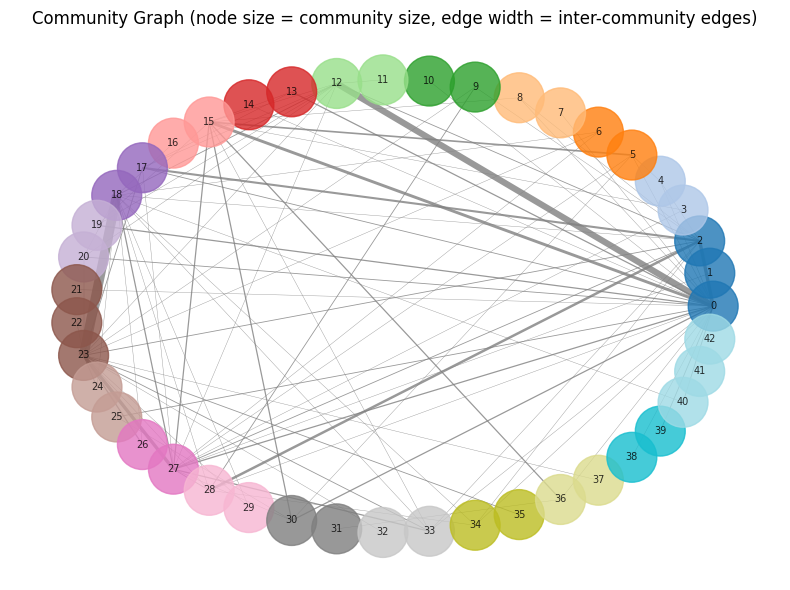

In [ ]:
# pick a timestep with enough nodes to be interesting
TIMESTEP = 25
                                                                                                                            
# filter nodes and edges for this timestep
ts_nodes = df[df['time_step'] == TIMESTEP]['txId'].values                                                                  
ts_edges = edges[edges['txId1'].isin(ts_nodes) & edges['txId2'].isin(ts_nodes)]                                            
                                                                                                                            
# build graph for this timestep                                                                                            
G_ts = nx.from_pandas_edgelist(                                                                                            
    ts_edges, source='txId1', target='txId2'
)                                                                                                                          
# keep only nodes that appear in the edgelist (drop isolates)
print(f"Timestep {TIMESTEP}: {G_ts.number_of_nodes()} nodes, {G_ts.number_of_edges()} edges")                              
                                                                                                                            
# Louvain on single timestep                                                                                               
comms_ts = community.louvain_communities(G_ts, seed=RANDOM_STATE) 
n_comms_ts = len(comms_ts)                                                                    
node_to_community_ts = {}                                                                                                  
for i, group in enumerate(comms_ts):
    for node in group:                                                                                                     
        node_to_community_ts[node] = i

print(f"Communities found: {len(comms_ts)}")                                                                               
print(f"Community sizes: {sorted([len(c) for c in comms_ts], reverse=True)[:10]}")

comm_graph = nx.Graph()                                                                                                    
for i, comm in enumerate(comms_ts):
    comm_graph.add_node(i, size=len(comms_ts))                                                                                 
                                                                                                                            
for u, v in G_max.edges():
    cu, cv = node_to_community[u], node_to_community[v]                                                                    
    if cu != cv:                                       
        if comm_graph.has_edge(cu, cv):
            comm_graph[cu][cv]['weight'] = comm_graph[cu][cv].get('weight', 1) + 1                                         
        else:                                                                     
            comm_graph.add_edge(cu, cv, weight=1)                                                                          
                                                                                                                            
sizes  = [comm_graph.nodes[i]['size'] * 30 for i in comm_graph.nodes()]
widths = [comm_graph[u][v]['weight'] * 0.3 for u, v in comm_graph.edges()]                                                 
                                                                        
fig, ax = plt.subplots(figsize=(8, 6))                                                                                     
pos = nx.circular_layout(comm_graph)
nx.draw(comm_graph, pos, ax=ax,                                                                                            
        node_size=sizes, width=widths,                                                                                     
        node_color=range(n_comms_ts), cmap=plt.get_cmap('tab20', n_comms_ts),
        edge_color='grey', alpha=0.8, with_labels=True, font_size=7)                                                       
ax.set_title('Community Graph (node size = community size, edge width = inter-community edges)')
plt.tight_layout()                                                                                                         
plt.show() 

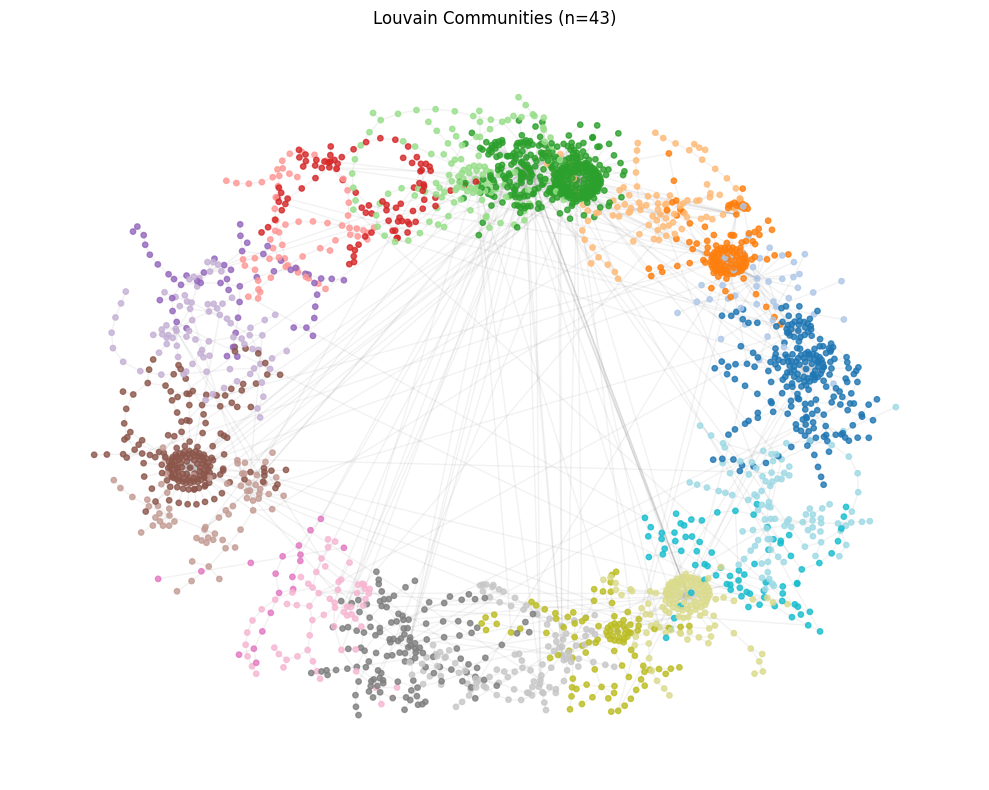

In [80]:
fig, ax = plt.subplots(figsize=(10, 8))
pos = community_layout(G_ts, comms_ts)                                                                                       

cmap = plt.get_cmap('tab20', n_comms_ts)                                                       
node_colors = [node_to_community_ts[n] for n in G_ts.nodes()]          
                                                                                                                            
nx.draw_networkx_nodes(G_ts, pos, node_color=node_colors, node_size=15,                                                   
                        cmap=cmap, alpha=0.8, ax=ax)                                                                        
nx.draw_networkx_edges(G_ts, pos, alpha=0.1, edge_color='grey', ax=ax)                                                    
ax.set_title(f'Louvain Communities (n={n_comms_ts})')                                                                         
ax.axis('off')                                                                                                             
plt.tight_layout()                                                                                                         
plt.show() 

Looks for density of edges. It groups nodes that are more connected to each other than to the rest of the network
The algorithm works in 2 steps. On the first step it assigns every node to be in its own community and then for each node it tries to find the maximum positive modularity gain by moving each node to all of its neighbor communities. If no positive gain is achieved the node remains in its original community.

### K Core decomposition

The K-core of a graph G is the maximal subgraph $H \subset G$, such that the degree of h $\delta(H) \geq K$

so every node in H is neighbor (adjacent) to at least k other nodes, iteratively

The k-core value is unique to every k. 

This returns dense communities within the graph. Seidman 1983
https://www.youtube.com/watch?v=ZI5VUkUAcwg 

used for distinguishing between organized entities like exchanges or fraud rings and casual users.

k-Core: A global hierarchical decomposition based purely on node degree. It tells you how "deep" a node is in the network's skeleton.

it measures connectivity of more than first degree neighborhood, revealing to which structure a node belongs to.
A k-core is a maximal subgraph where every node has a degree of at least $k$ within that subgraph.
To find the 3-core, recursively remove all nodes with degree less than 3 until only a stable "core" remains where everyone left has at least 3 neighbors who are also still in the core.
High K-core (The Nucleus): Often represents "Fraud Rings" or "Mixers". These are groups where everyone is transacting with everyone else to obfuscate the money trail. They form a "tight cluster" that survives deep levels of pruning.
Low K-core (The Periphery): These are "Money Mules" or legitimate "One-time Users". They may have a high degree (connected to one big hub), but they are easily pruned because they aren't part of a mutually connected inner circle.

In [81]:
# Calculate core numbers for all nodes
core_numbers = nx.core_number(G_max)        
max_k = max(core_numbers.values())
max_k


3

In [82]:

# To get a specific k-core (e.g., the 5-core)
innermost_core = nx.k_core(G_max, k=max_k) #2


In [83]:
# find nodes labels
label_map = dict(zip(classes['txId'], classes['class']))
inner_labels = [label_map.get(node) for node in innermost_core.nodes()]


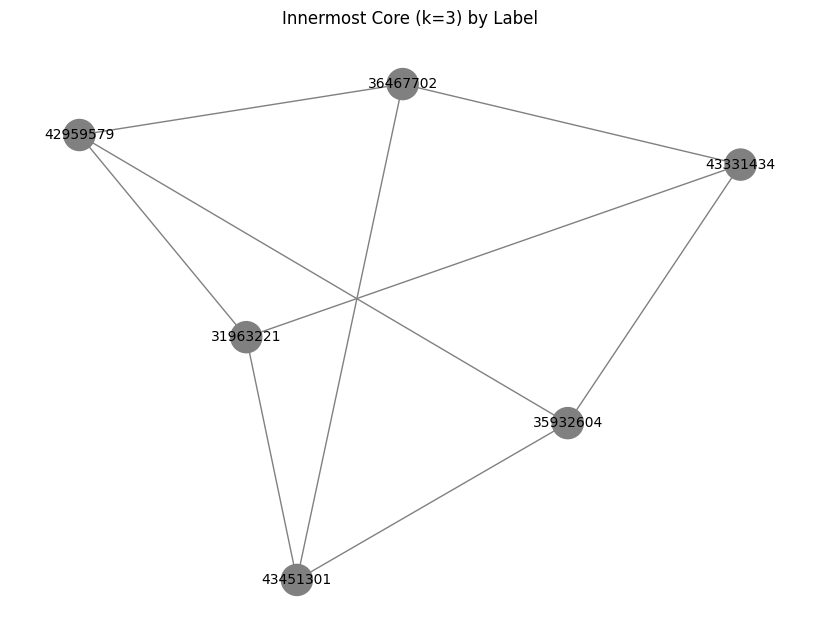

In [84]:
plt.figure(figsize=(8, 6))

# Use a layout for visualization (spring_layout is common)
pos = nx.spring_layout(innermost_core, seed=RANDOM_STATE)

# assign colors by class labels
color_dict = {0: 'green', 1: 'red', 2: 'grey'}
node_colors = [color_dict[label] for label in inner_labels]

nx.draw(innermost_core, pos, 
        with_labels=True, 
        node_size=500, 
        node_color=node_colors,
        edge_color='gray', 
        font_size=10)

plt.title(f"Innermost Core (k={max_k}) by Label")
plt.axis('off')
plt.show()

the max core in the entire graph is 9.
for the subgraph is 2

this means -
No "Dense Hubs": In many financial networks, you expect a high k-max (e.g., 10, 20, or 50) because exchanges or big wallets form "cliques" where they all talk to each other. A k-max of 2 means your graph is mostly made of trees, paths, and simple cycles.

Most nodes are "Peripheral": Most of your nodes are likely in the 1-shell (connected by a single edge to the rest of the graph) or the 2-shell (part of a simple loop or a chain).

Tree-like Transactions: Bitcoin transactions often follow a "UTXO" flow: Input → Output → Change. This creates a flow that looks like a Directed Acyclic Graph (DAG) or a tree. Trees always have a k-core of 1. If you have a few simple loops, the k-core stays at 2.
